# Our Simple Quick Run Script

- First, we will load simple python libraries that should come preloaded.

In [1]:
import os
import torch
import numpy as np

from torch_brain.utils import seed_everything

In [2]:
seed_everything(0)

base_dir = os.getcwd().split("additional")[0]
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using: {device}")

Using: cpu


## Loading the Data

In [3]:
from neural_decode.dataset.transformer_dataloader import get_train_val_loaders

In [4]:
path_to_neural_dataset = os.path.join(base_dir, "data", "perich_miller_population_2018", "t_20130819_center_out_reaching")
train_dataset, train_loader, val_dataset, val_loader = get_train_val_loaders(path_to_neural_dataset, batch_size=64)

num_units = len(train_dataset.get_unit_ids())
print()
print(f"Batches in Train Dataset: {len(train_loader)}")
print(f"Batches in Val Dataset: {len(val_loader)}")
print(f"Num Units in Session: {num_units}")


Batches in Train Dataset: 10
Batches in Val Dataset: 2
Num Units in Session: 55


## Loading a Model

In [5]:
from neural_decode.models.transformer import TransformerNeuralDecoder 
from neural_decode.models.hopfield_only import HopfieldOnlyDecoder
from neural_decode.models.transformer_hopfield import TransformerHopfieldDecoder

In [6]:
tf_model = TransformerNeuralDecoder(
    num_units=num_units,
    bin_size=10e-3,
    sequence_length=1.0,
    dim_output=2,
    dim_hidden=128,
    n_layers=3,
    n_heads=4,
).to(device)

hopfield_only_model = HopfieldOnlyDecoder(
    num_units=num_units,
    bin_size=10e-3,
    sequence_length=1.0,
    dim_output=2,
    dim_hidden=128,
    n_layers=3,
).to(device)

tf_hopfield_model = TransformerHopfieldDecoder(
    num_units=num_units,
    bin_size=10e-3,
    sequence_length=1.0,
    dim_output=2,
    dim_hidden=128,
    n_layers=3,
    n_heads=4,
).to(device)


In [7]:
print(tf_model)

TransformerNeuralDecoder(
  (readin): Linear(in_features=55, out_features=128, bias=True)
  (readout): Linear(in_features=128, out_features=2, bias=True)
  (transformer_layers): ModuleList(
    (0-2): 3 x ModuleList(
      (0): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (1): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=1024, bias=True)
          (1): GEGLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
        )
      )
    )
  )
)


In [8]:
print(hopfield_only_model)

HopfieldOnlyDecoder(
  (readin): Linear(in_features=55, out_features=128, bias=True)
  (readout): Linear(in_features=128, out_features=2, bias=True)
  (layers): ModuleList(
    (0-2): 3 x ModuleList(
      (0): Hopfield(
        (association_core): HopfieldCore(
          (out_proj): Linear(in_features=512, out_features=128, bias=True)
        )
        (norm_stored_pattern): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm_state_pattern): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm_pattern_projection): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      )
      (1): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=1024, bias=True)
          (1): GEGLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
        )
      )
    )
  )
)


In [9]:
print(tf_hopfield_model)

TransformerHopfieldDecoder(
  (readin): Linear(in_features=55, out_features=128, bias=True)
  (readout): Linear(in_features=128, out_features=2, bias=True)
  (transformer_layers): ModuleList(
    (0-2): 3 x ModuleList(
      (0): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (1): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=1024, bias=True)
          (1): GEGLU()
          (2): Dropout(p=0.2, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
        )
      )
    )
  )
  (hopfield): Hopfield(
    (association_core): HopfieldCore(
      (out_proj): Linear(in_features=512, out_features=128, bias=True)
    )
    (norm_stored_pattern): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (norm_state_pattern): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (norm_pattern_projection): LayerNorm((128,), eps=1e-05, 

## Training a Model

In [10]:
from neural_decode.training.train_model import train

In [11]:
train_dataset.transform = tf_model.tokenize
val_dataset.transform = tf_model.tokenize

optimizer = torch.optim.AdamW(tf_model.parameters(), lr=1e-3)

In [12]:
transformer_r2_log_tf, transformer_loss_log_tf, transformer_train_outputs_tf = train(tf_model, optimizer, train_loader, val_loader,
                                                                            num_epochs=3, device = device)

print()

transformer_r2_log_hop, transformer_loss_log_hop, transformer_train_outputs_hop = train(hopfield_only_model, optimizer, train_loader, val_loader,
                                                                            num_epochs=3, device = device)

print()

transformer_r2_log_tf_hop, transformer_loss_log_tf_hop, transformer_train_outputs_tf_hop = train(tf_hopfield_model, optimizer, train_loader, val_loader,
                                                                            num_epochs=3, device = device)

Epoch 3/3 | Val R2 = -0.005 | Loss = 19.142
Done! Final validation R2 = 0.001

Epoch 3/3 | Val R2 = -0.012 | Loss = 15.322
Done! Final validation R2 = -0.012

Epoch 3/3 | Val R2 = -0.005 | Loss = 19.954
Done! Final validation R2 = -0.005


## Evaluating a Model

In [13]:
from neural_decode.evaluation.graphing_functions import plot_training_curves

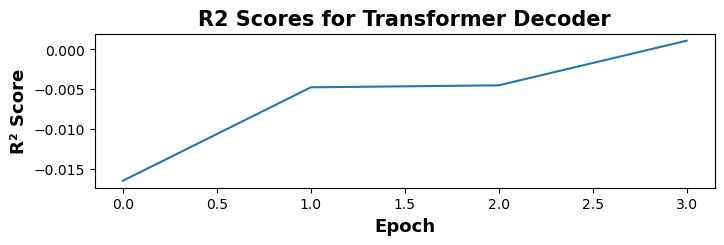

In [14]:
fig_plot = plot_training_curves(transformer_r2_log_tf, "R2 Scores for Transformer Decoder")

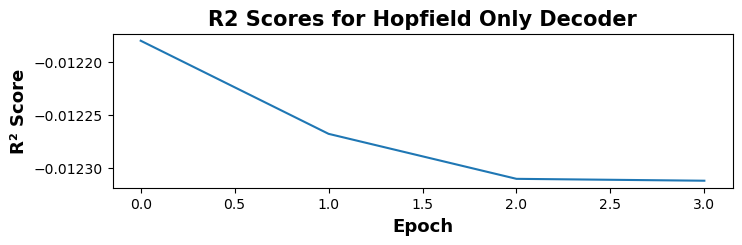

In [15]:
fig_plot = plot_training_curves(transformer_r2_log_hop, "R2 Scores for Hopfield Only Decoder")

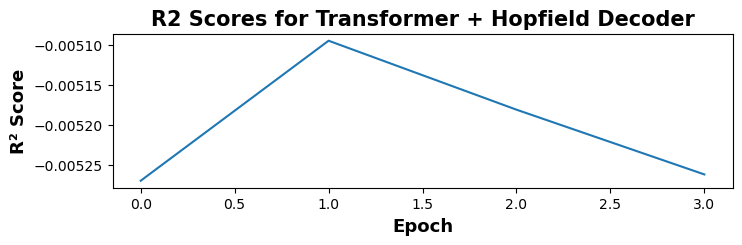

In [16]:
fig_plot = plot_training_curves(transformer_r2_log_tf_hop, "R2 Scores for Transformer + Hopfield Decoder")

## Saliency Based Analysis

In [17]:
from neural_decode.post_hoc_analysis.saliency_based_analysis import compute_and_return_attribution_maps

In [18]:
sal_maps = compute_and_return_attribution_maps(tf_hopfield_model, val_loader)

In [19]:
print(f"Saliency Maps Shape: {sal_maps.shape}")
print(f"Min Value in Saliency Maps: {np.min(sal_maps)}")
print(f"Max Value in Saliency Maps: {np.max(sal_maps)}")

Saliency Maps Shape: (73, 100, 55)
Min Value in Saliency Maps: 0.0
Max Value in Saliency Maps: 1.0
